In [2]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt 
import random 

In [3]:
words = open('names.txt', 'r').read().splitlines()
print(words[:5])
print(len(words))


['emma', 'olivia', 'ava', 'isabella', 'sophia']
32033


In [4]:
# building the vocabulary of characters and mappings to integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i +1 for i, s in enumerate(chars)}  # string to index
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()} # index to string
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


**First pass: single split, no train/dev/test**
A simple forward pass is performed.

In [5]:
# building the dataset

block_size = 3 # context_length: how many characters are taken to predict the next one
X, Y = [], []
for w in words:

    
    context = [0]* block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(index_to_string[i] for i in context), '----->', index_to_string[ix])
        context = context[1:]+ [ix] # crop and append


X = torch.tensor(X)
Y = torch.tensor(Y)

X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [6]:
#Building embedding of characters
C = torch.randn((27, 2)) #lookup table with 2 dim embedding for each character

 # F.one_hot(torch.tensor(5), num_classes=27) # alternative embedding 

emb = C[X]

# hidden layer
W1 = torch.randn((6,100))  # 2 dim embeddings for 3 input neurons ---> 6 
b1 = torch.randn(100)

h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1) 
#print(h.shape)

#Alternatives methods
# a = torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]],1)
# a = torch.arange(18)    



#output layer
W2 = torch.randn((100,27))
b2 = torch.randn(27)

logits = h @ W2 + b2
# counts = logits.exp()
# prob = counts / counts.sum(1 , keepdims = True)
# loss = -prob[torch.arange(32), Y].log().mean() use F.cross_entropy for efficiency and simplicity
F.cross_entropy(logits, Y)


tensor(14.8015)

-----
**Proper setup: train/dev/test split, Learning Rate search, minibatch training**

In [7]:
# building the dataset

block_size = 3 # context_length: how many characters are taken to predict the next one


def build_dataset(words):
    X, Y = [], []
    for w in words:

        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:]+ [ix] 


    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtrain, Ytrain = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [13]:
# Parameters initialisation

g = torch.Generator().manual_seed(2147483647)

C = torch.randn((27,10), generator = g) # embedding space: intially (27,2)
W1 = torch.randn((30,300), generator= g)  # initial hidden layer,  n=100 neurons
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, W2, b1, b2]


for p in parameters:
    p.requires_grad = True

print('Total parameters:',sum(p.nelement() for p in parameters))

Total parameters: 17697


Text(0, 0.5, 'loss')

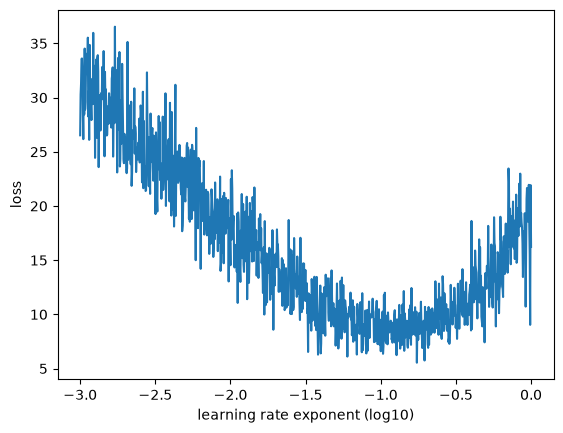

In [12]:
# Learning rate search: I sweep the learning rate exponentially from 0.001 to 1.0 over exactly 1000 steps

lre = torch.linspace(-3, 0, 1000) #search for lr exponents (from -3 to 0)
lrv =10 ** lre # actual lr values from 0.001 to 1

lr_log = []
loss_log = []

for i in range(1000):

    #minibatch construct
    ix = torch.randint(0, Xtrain.shape[0], (32,)) 

    # forward pass
    emb = C[Xtrain[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytrain[ix])

    # backward pass
    for p in parameters:
        p.grad = None 
    loss.backward()

    #update
    lr =lrv[i]
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    lr_log.append(lre[i].item())
    loss_log.append(loss.item())

plt.plot(lr_log,  loss_log)
plt.xlabel('learning rate exponent (log10)')
plt.ylabel('loss')

**Interpretation**:  the plot loss has a valley-like shape: loss drops, reaches the minimum out, then rises again as the learning rate gets too big. 

In [14]:
# WARNING: BEFORE RUNNING THIS CELL, RE-INITIALIZE THE PARAMETERS

learning_rate = 0.03   #  the value corresponding to log(-1) in the plot

train_step_log = []
train_loss_log = []


for i in range(200000):
  
  ix = torch.randint(0, Xtrain.shape[0], (32,))   # minibatch construct

  # forward pass
  emb = C[Xtrain[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytrain[ix])
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  for p in parameters:
    p.data += -learning_rate * p.grad

  # track stats
  train_step_log.append(i)
  train_loss_log.append(loss.item())

print(loss.item())

2.218637466430664


Text(0, 0.5, 'loss')

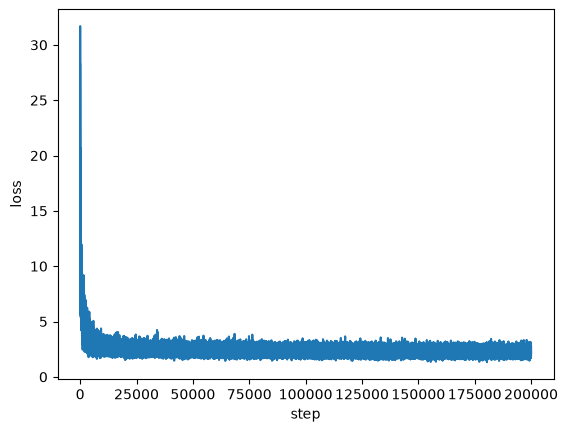

In [15]:
plt.plot(train_step_log, train_loss_log)
plt.xlabel('step')
plt.ylabel('loss')

In [16]:
emb = C[Xtrain]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytrain)
loss

tensor(2.2401, grad_fn=<NllLossBackward0>)

In [17]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2772, grad_fn=<NllLossBackward0>)

In [18]:
# final result
emb = C[Xtest]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytest)
loss

tensor(2.2805, grad_fn=<NllLossBackward0>)

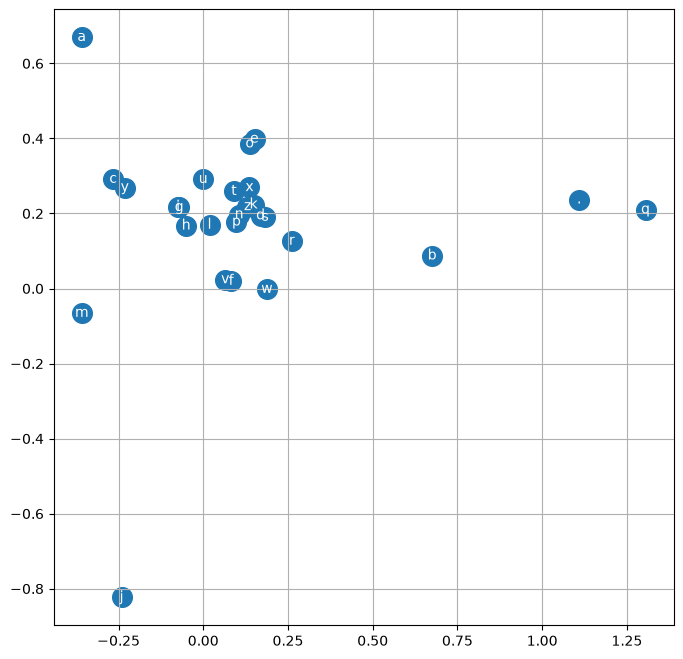

In [19]:
# Visualizing character embeddings

plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor') 

In [20]:
# Sampling new names from the model 
 
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size  
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

carlah.
amirie.
khi.
mili.
taty.
salaysie.
rahnen.
averric.
kaqui.
neraniah.
maiiy.
kaleigh.
ham.
jossiquint.
salin.
alianni.
watelo.
diaryni.
jaxeenivuan.
edaya.


Hyperparameters tuning configs:

n_neurons hidden later: 100 > 300 > 500
n_embeddings: 2 > 10
lr = 0.1 > 0.01

decay: dev 2.41, dev 2.67


------------------

n_neurons hidden later:  300 
n_embeddings: 10
lr = 0.1 

decay: dev 2.40, tst 2.41

---------------------
n_neurons hidden later:  300 
n_embeddings: 10
lr = 0.05 

decay: dev 2.25, tst 2.30

-----------------------
n_neurons hidden later:  300 
n_embeddings: 10
lr = 0.05 

decay: dev 2.25, tst 2.30



-----------------------
n_neurons hidden later:  300 
n_embeddings: 10
lr = 0.03 

decay: dev 2.24, tst 2.27



